# EDA — SECOP II (Fase 3)

Exploracion de `contracts.parquet` (datos deduplicados, ANTES del filtro de negocio de `build_features.py`) para justificar con datos las decisiones ya tomadas: rango de `valor_contrato`, `ESTADOS_VALIDOS`, fechas de ejecucion obligatorias, y el diseno de `concentracion_proveedor` y `valor_vs_promedio_categoria`.

**Nota de recursos:** el archivo pesa ~2.4 GB y esta maquina tiene RAM limitada (~6GB). Todo lo que agrega/filtra se hace con DuckDB (fuera de memoria); solo se traen a pandas muestras pequenas para graficar (mismo patron usado en `build_features.py` para evitar el OOM ya documentado).

In [1]:
import sys

print(sys.executable)

c:\Users\ACER\Documents\Developer\MLops\curso\MLOps_Secop\.venv\Scripts\python.exe


In [2]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute("SET memory_limit='1.5GB'")
con.execute("SET preserve_insertion_order=false")

PARQUET = "../data/processed/secop_ii/contracts.parquet"

## 1. Tamano y esquema

In [3]:
con.execute(f"SELECT COUNT(*) AS n_filas FROM read_parquet('{PARQUET}')").fetchdf()

,n_filas
0,8143661


In [4]:
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET}') LIMIT 1").fetchdf()

,column_name,column_type,null,key,default,extra
0,nivel_entidad,VARCHAR,YES,None,None,None
1,codigo_entidad_en_secop,VARCHAR,YES,None,None,None
2,nombre_de_la_entidad,VARCHAR,YES,None,None,None
3,nit_de_la_entidad,VARCHAR,YES,None,None,None
4,departamento_entidad,VARCHAR,YES,None,None,None
5,municipio_entidad,VARCHAR,YES,None,None,None
6,estado_del_proceso,VARCHAR,YES,None,None,None
7,modalidad_de_contrataci_n,VARCHAR,YES,None,None,None
8,objeto_a_contratar,VARCHAR,YES,None,None,None
9,objeto_del_proceso,VARCHAR,YES,None,None,None


## 2. Valores nulos en columnas clave

In [5]:
cols_clave = [
    "valor_contrato",
    "estado_del_proceso",
    "fecha_de_firma_del_contrato",
    "fecha_inicio_ejecuci_n",
    "fecha_fin_ejecuci_n",
    "documento_proveedor",
    "modalidad_de_contrataci_n",
    "departamento_entidad",
]
nulos_expr = ", ".join(
    f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS nulos_{c}" for c in cols_clave
)
con.execute(
    f"SELECT {nulos_expr}, COUNT(*) AS total FROM read_parquet('{PARQUET}')"
).fetchdf().T

,0
nulos_valor_contrato,0.0
nulos_estado_del_proceso,0.0
nulos_fecha_de_firma_del_contrato,0.0
nulos_fecha_inicio_ejecuci_n,968759.0
nulos_fecha_fin_ejecuci_n,66.0
nulos_documento_proveedor,1.0
nulos_modalidad_de_contrataci_n,0.0
nulos_departamento_entidad,0.0
total,8143661.0


## 3. Distribucion de `valor_contrato` (antes del filtro de negocio)

In [6]:
con.execute(f"""
    SELECT
        COUNT(*) AS n,
        MIN(TRY_CAST(valor_contrato AS DOUBLE)) AS minimo,
        approx_quantile(TRY_CAST(valor_contrato AS DOUBLE), 0.5) AS mediana,
        AVG(TRY_CAST(valor_contrato AS DOUBLE)) AS promedio,
        approx_quantile(TRY_CAST(valor_contrato AS DOUBLE), 0.95) AS p95,
        approx_quantile(TRY_CAST(valor_contrato AS DOUBLE), 0.99) AS p99,
        MAX(TRY_CAST(valor_contrato AS DOUBLE)) AS maximo
    FROM read_parquet('{PARQUET}')
    WHERE TRY_CAST(valor_contrato AS DOUBLE) IS NOT NULL
""").fetchdf()

,n,minimo,mediana,promedio,p95,p99,maximo
0,8143661,0.0,1.727247e+07,3.157651e+08,2.132280e+08,2.274406e+09,9.441873e+14


Con esta distribucion tan sesgada (tipico en valores monetarios) se justifica por que `build_features.py` filtra por `VALOR_MIN=1,000,000` / `VALOR_MAX=200,000,000` (`config.py`): se busca la zona donde se concentra la mayoria de la contratacion publica real, evitando registros basura (valores en 0 o casi 0) y outliers extremos de magnitud que distorsionarian `valor_vs_promedio_categoria`.

In [7]:
con.execute(f"""
    SELECT
        COUNT(*) AS total_con_valor,
        SUM(CASE WHEN TRY_CAST(valor_contrato AS DOUBLE)
            BETWEEN 1000000 AND 200000000 THEN 1 ELSE 0 END) AS dentro_del_rango,
        ROUND(100.0 * SUM(CASE WHEN TRY_CAST(valor_contrato AS DOUBLE)
            BETWEEN 1000000 AND 200000000 THEN 1 ELSE 0 END) / COUNT(*), 2)
            AS pct_dentro_del_rango
    FROM read_parquet('{PARQUET}')
    WHERE TRY_CAST(valor_contrato AS DOUBLE) IS NOT NULL
""").fetchdf()

,total_con_valor,dentro_del_rango,pct_dentro_del_rango
0,8143661,7204400.0,88.47


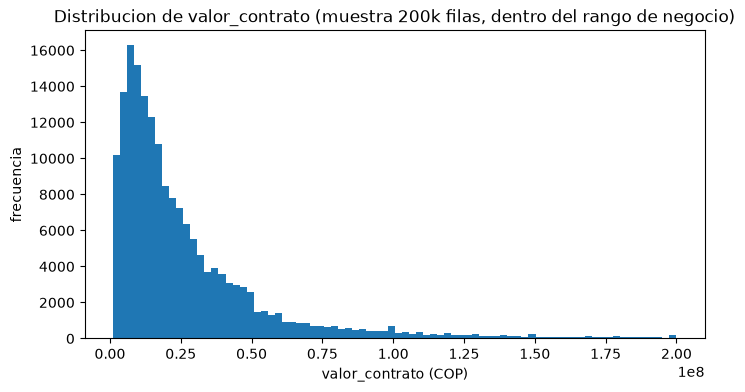

In [8]:
muestra = con.execute(f"""
    SELECT TRY_CAST(valor_contrato AS DOUBLE) AS valor_contrato
    FROM read_parquet('{PARQUET}')
    WHERE TRY_CAST(valor_contrato AS DOUBLE) BETWEEN 1000000 AND 200000000
    USING SAMPLE 200000 ROWS
""").fetchdf()

plt.figure(figsize=(8, 4))
plt.hist(muestra["valor_contrato"], bins=80)
plt.title(
    "Distribucion de valor_contrato (muestra 200k filas, dentro del rango de negocio)"
)
plt.xlabel("valor_contrato (COP)")
plt.ylabel("frecuencia")
plt.show()

## 4. Estados del proceso (`estado_del_proceso`)

In [9]:
con.execute(f"""
    SELECT LOWER(estado_del_proceso) AS estado, COUNT(*) AS n
    FROM read_parquet('{PARQUET}')
    GROUP BY 1
    ORDER BY n DESC
""").fetchdf()

,estado,n
0,en ejecución,1853492
1,modificado,1534151
2,celebrado,1479503
3,cerrado,1161526
4,terminado,695904
5,aprobado,566898
6,activo,403956
7,liquidado,330959
8,cedido,41508
9,suspendido,36740


El dataset real tiene inconsistencias de mayusculas/minusculas en este campo (confirmado empiricamente, ver comentario en `config.py`), por eso el filtro siempre compara en minusculas. `ESTADOS_VALIDOS` mantiene los estados que implican ejecucion real del contrato (`celebrado`, `adjudicado`, `en ejecucion`, `liquidado`, `terminado`, `terminado sin liquidar`, `modificado`, `cerrado`) y excluye estados previos a la ejecucion (`borrador`, `convocado`, `aprobado`, `activo`) y estados anomalos del proceso (`cancelado`, `suspendido`), que no son comparables por valor con contratos ejecutados normalmente.

## 5. Fechas de ejecucion (`fecha_inicio_ejecuci_n` / `fecha_fin_ejecuci_n`)

In [10]:
con.execute(f"""
    SELECT
        SUM(CASE WHEN TRY_CAST(fecha_inicio_ejecuci_n AS DATE) IS NULL
            THEN 1 ELSE 0 END) AS inicio_nulo,
        SUM(CASE WHEN TRY_CAST(fecha_fin_ejecuci_n AS DATE) IS NULL
            THEN 1 ELSE 0 END) AS fin_nulo,
        SUM(CASE
            WHEN TRY_CAST(fecha_fin_ejecuci_n AS DATE)
                < TRY_CAST(fecha_inicio_ejecuci_n AS DATE)
            THEN 1 ELSE 0
        END) AS fin_antes_de_inicio,
        COUNT(*) AS total
    FROM read_parquet('{PARQUET}')
""").fetchdf()

,inicio_nulo,fin_nulo,fin_antes_de_inicio,total
0,968759.0,66.0,742.0,8143661


Justifica por que `build_features.py` exige que ambas fechas existan y que `fecha_fin_ejecuci_n >= fecha_inicio_ejecuci_n`: sin eso, `duracion_dias` no se puede calcular o sale negativa/sin sentido.

## 6. Contratos por ano — motivo de la limitacion de IPC ya documentada

In [11]:
con.execute(f"""
    SELECT
        YEAR(TRY_CAST(fecha_de_firma_del_contrato AS DATE)) AS anio,
        COUNT(*) AS n_contratos,
        ROUND(AVG(TRY_CAST(valor_contrato AS DOUBLE)), 0) AS valor_promedio_nominal
    FROM read_parquet('{PARQUET}')
    WHERE TRY_CAST(valor_contrato AS DOUBLE) BETWEEN 1000000 AND 200000000
      AND TRY_CAST(fecha_de_firma_del_contrato AS DATE) IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

,anio,n_contratos,valor_promedio_nominal
0,2022,1237172,23082651.0
1,2023,1215296,25914450.0
2,2024,1706517,25811319.0
3,2025,1929293,29586413.0
4,2026,1116122,30405189.0


Si el valor promedio nominal por ano sube con el tiempo, parte es inflacion (IPC), no necesariamente contratos mas grandes. Esta es la limitacion ya documentada en el resumen de gobernanza del proyecto: `valor_vs_promedio_categoria` compara contra el promedio de TODO el historico en pesos nominales, lo que puede sesgar contratos recientes como 'mas caros que el promedio' solo por la inflacion acumulada.

## 7. Concentracion por proveedor (`documento_proveedor`)

In [12]:
con.execute(f"""
    WITH conteo AS (
        SELECT documento_proveedor, COUNT(*) AS n_contratos
        FROM read_parquet('{PARQUET}')
        WHERE documento_proveedor IS NOT NULL
        GROUP BY 1
    )
    SELECT
        MIN(n_contratos) AS minimo,
        approx_quantile(n_contratos, 0.5) AS mediana,
        approx_quantile(n_contratos, 0.95) AS p95,
        approx_quantile(n_contratos, 0.99) AS p99,
        MAX(n_contratos) AS maximo,
        COUNT(*) AS n_proveedores_distintos
    FROM conteo
""").fetchdf()

,minimo,mediana,p95,p99,maximo,n_proveedores_distintos
0,1,3,16,29,117308,1406365


La mayoria de los proveedores tienen pocos contratos, pero se espera una cola larga de proveedores con muchisimos — justifica `concentracion_proveedor` como feature (un proveedor con concentracion muy alta puede ser una senal relevante para el analisis de anomalias, en cualquier direccion: dependencia del Estado en pocos proveedores, o legitima especializacion).

## 8. Cardinalidad de columnas categoricas usadas en el modelo

In [13]:
for col in ["modalidad_de_contrataci_n", "departamento_entidad", "tipo_de_contrato"]:
    n = con.execute(
        f"SELECT COUNT(DISTINCT {col}) FROM read_parquet('{PARQUET}')"
    ).fetchone()[0]
    print(f"{col}: {n} valores distintos")

modalidad_de_contrataci_n: 30 valores distintos
departamento_entidad: 38 valores distintos
tipo_de_contrato: 32 valores distintos


## Conclusiones — de la EDA a las decisiones de `build_features.py`

- **Rango `VALOR_MIN`/`VALOR_MAX` (1M-200M COP):** recorta la cola larga de valores extremos/atipicos de magnitud y descarta contratos con valor ~0 (probable dato basura), sin perder la mayoria real del volumen de contratacion.
- **`ESTADOS_VALIDOS`:** se mantienen solo estados que implican ejecucion real y comparable; se descartan estados previos al inicio (no hay valor de ejecucion que comparar) y estados anomalos del proceso (cancelado/suspendido).
- **Fechas de ejecucion validas y coherentes (`fin >= inicio`):** sin esto, `duracion_dias` no tiene sentido.
- **`concentracion_proveedor`:** la cola larga de proveedores con muchos contratos justifica incluirla como feature de interes.
- **Limitacion confirmada por esta EDA (ya documentada en gobernanza):** si el valor promedio nominal crece por ano, el pipeline no esta ajustando por inflacion (IPC), lo cual puede sesgar `valor_vs_promedio_categoria` a favor de ver contratos recientes como mas "caros" de lo normal. Pendiente de decision: normalizar por ano en `build_features.py` si hay tiempo antes del 12/9.